# Práctica 3: A\*, Hill Climbing y Optimización de Redes

Fabian Prado - 23427 | CC3074 Modelación y Simulación, UVG | 2026-10-06

**Pregunta:** ¿Qué solución encuentran Hill Climbing, A\*, Edmonds-Karp y el flujo de costo mínimo en sus tres problemas, y cómo se comprueba si es la mejor posible?

El laboratorio tiene tres problemas, cada uno con su algoritmo:

1. **Hill Climbing** para el agente viajero: recorrer las ciudades 2 a 7 saliendo y volviendo a la ciudad 1 con la menor distancia.
2. **A\*** para la ruta más corta de O a T en la red del guardabosques.
3. **Flujo Máximo (Edmonds-Karp) y Costo Mínimo** para enviar suministros de S a T.

Todos los algoritmos están implementados desde cero, solo con la librería estándar de Python (`heapq`, `collections`, `random`, `itertools`, `math`) y `matplotlib` para las gráficas, como pide el enunciado.

## Mapa del notebook

1. Imports y configuración
2. Obtención de datos
3. Preparación de datos
4. Variables
5. Modelos y métricas
6. Gráficas
7. Ejecución
8. Conclusiones

Las secciones 2 a 6 solo definen funciones, separadas por parte. La sección 7 las ejecuta en orden y cada resultado lleva su interpretación.

## Dónde está cada actividad

| Parte | Actividades del enunciado | Paso en la sección 7 |
|---|---|---|
| 1. Hill Climbing | 1. `distancia_tour` y tour inicial | 7.1 |
| | 2. `vecinos` por inversión | 7.2 |
| | 3 y 4. Hill Climbing de máximo descenso con registro | 7.3 |
| | 5. 100 reinicios aleatorios | 7.4 |
| | Extra: todos los tours válidos por fuerza bruta | 7.5 |
| | 6. Gráfica del mejor recorrido | 7.6 |
| | Preguntas de análisis | después de 7.6 |
| 2. A\* | 7. `heuristica` euclidiana | 7.7 |
| | 8, 9 y 10. A\* con `heapq`, registro, ruta y costo | 7.8 |
| | 11. A\* con h(n) = 0 | 7.9 |
| | 12. Gráfica de la red | 7.10 |
| | Preguntas de análisis | después de 7.10 |
| 3A. Flujo Máximo | 13. Red residual | 7.11 |
| | 14, 15 y 16. Edmonds-Karp con registro y flujo por tramo | 7.12 |
| | 17. Verificación de capacidad y conservación | 7.13 |
| | Extra: corte mínimo | 7.14 |
| 3B. Costo Mínimo | 18. Capacidad, costo y flujo por arista | 7.15 |
| | 19 a 23. Costo mínimo con registro | 7.16 |
| | 24. Reporte final | 7.17 |
| | Extra: costo de la distribución de Edmonds-Karp | 7.18 |
| | Preguntas de análisis | después de 7.18 |
| Integración | Tabla comparativa y conclusión | 8 |

## 1. Imports y configuración

Todas las librerías, la semilla y la paleta en una sola celda. Solo se usan las librerías que permite el enunciado: nada de `numpy`, `pandas` ni `networkx`, así que las tablas se imprimen con texto. `SEED` fija los reinicios aleatorios de Hill Climbing para que cualquier corrida dé los mismos números.

In [1]:
import heapq
import itertools
import math
import random
from collections import Counter, deque
from pathlib import Path

import matplotlib.pyplot as plt

SEED = 42
ROOT = Path.cwd()
FIG_DIR = ROOT / "figuras"
FIG_DIR.mkdir(exist_ok=True)

# Forest, leaf, ochre, lake, clay: greens first, earth and water tones for more series.
PALETTE = ["#0E4D45", "#3F8A26", "#B07D2B", "#3A7CA5", "#A4493D"]
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
    "figure.figsize": (16, 9),
    "figure.facecolor": "white",
    "legend.frameon": True,
})

## 2. Obtención de datos

No hay archivos externos: los datos de cada parte se copian del enunciado en una función que los devuelve tal cual.

- **Parte 1.** `get_carreteras`: las 13 carreteras entre las 7 ciudades como (ciudad, ciudad, distancia). Son de doble sentido. Si un par de ciudades no aparece, no hay carretera directa entre ellas.

In [2]:
# Part 1: traveling salesman
def get_carreteras():
    """Roads of part 1 as (city, city, distance). Two-way; a pair that is not listed has no road."""
    return [
        (1, 2, 12), (1, 3, 10), (1, 7, 12),
        (2, 3, 8), (2, 4, 12),
        (3, 4, 11), (3, 5, 3), (3, 7, 9),
        (4, 5, 11), (4, 6, 10),
        (5, 6, 6), (5, 7, 7),
        (6, 7, 9),
    ]

## 3. Preparación de datos

Convierte los datos de cada parte a la estructura que usa su algoritmo.

- **Parte 1.** `construir_distancias`: tabla `distancias[a][b]` en los dos sentidos, porque las carreteras son de doble sentido. Un par sin carretera simplemente no está en la tabla, y así es fácil detectar un tour no válido.

In [3]:
# Part 1: traveling salesman
def construir_distancias(carreteras):
    """Symmetric table distancias[a][b]; a pair with no road is missing from the table."""
    distancias = {}
    for a, b, d in carreteras:
        distancias.setdefault(a, {})[b] = d
        distancias.setdefault(b, {})[a] = d
    return distancias

## 4. Variables

Aquí van las funciones que miden qué tan buena es una solución o un nodo: lo que cada algoritmo usa para decidir.

- **Parte 1.** `distancia_tour` es la **función objetivo** de Hill Climbing: suma la distancia de cada tramo del tour. Devuelve `None` (no válido) si un tramo usa una carretera que no existe, o si el tour no es un ciclo completo: debe empezar y terminar en la misma ciudad y pasar una sola vez por cada una de las demás.

In [4]:
# Part 1: objective function of Hill Climbing
def distancia_tour(tour, distancias):
    """Total distance of a closed tour, or None when it is not valid (missing road or not a full cycle)."""
    if tour[0] != tour[-1] or sorted(tour[:-1]) != sorted(distancias):
        return None
    total = 0
    for a, b in zip(tour, tour[1:]):
        if b not in distancias[a]:
            return None
        total += distancias[a][b]
    return total

## 5. Modelos y métricas

Los algoritmos de cada parte y la referencia contra la que se comparan.

| Parte | Algoritmo | Referencia | Métrica | Por qué esa métrica |
|---|---|---|---|---|
| 1 | Hill Climbing de máximo descenso, con y sin reinicios | Fuerza bruta sobre todos los tours (solo hay 720 órdenes posibles) | Distancia del tour y % de reinicios que llegan al óptimo | La fuerza bruta da la respuesta exacta, así que se sabe si Hill Climbing se quedó en un óptimo local |

**Parte 1, Hill Climbing.** Una **solución** es un tour que sale de la ciudad 1, pasa una vez por cada otra ciudad y vuelve a la 1. Un **vecino** es el tour que resulta de invertir un sub-recorrido: por ejemplo, invertir 3-4-5 en 1-2-3-4-5-6-7-1 da 1-2-5-4-3-6-7-1. La ciudad 1 nunca se mueve, así que con 6 ciudades libres hay 15 inversiones posibles. Un vecino que usa una carretera inexistente se descarta.

- `vecinos`: genera las 15 inversiones y devuelve las válidas con su distancia y el tramo invertido.
- `hill_climbing`: máximo descenso. En cada iteración evalúa **todos** los vecinos válidos y se mueve al de menor distancia, solo si es estrictamente mejor que el tour actual. Si ninguno mejora, se detiene: está en un **óptimo local**. Si hay empate entre vecinos, gana el primero en el orden en que se generan.
- `tour_aleatorio_valido` y `hill_climbing_reinicios`: repiten Hill Climbing desde tours al azar y se quedan con el mejor. El tour al azar se genera barajando las ciudades 2 a 7 hasta que salga uno válido, porque la mayoría de los órdenes usa alguna carretera que no existe.
- `fuerza_bruta_tours`: evalúa los 720 órdenes posibles. No es parte de Hill Climbing; sirve para saber cuál es el óptimo real.

In [5]:
# Part 1: Hill Climbing for the traveling salesman
def vecinos(tour, distancias, incluir_invalidos=False):
    """Tours made by reversing tour[i..j] with the first and last city fixed.

    Returns (neighbor, distance, reversed segment). Invalid neighbors are dropped, or kept with
    distance None when incluir_invalidos is True.
    """
    salida = []
    n = len(tour) - 1  # positions 0 and n hold the fixed start city
    for i in range(1, n - 1):
        for j in range(i + 1, n):
            vecino = tour[:i] + tour[i:j + 1][::-1] + tour[j + 1:]
            d = distancia_tour(vecino, distancias)
            if d is not None or incluir_invalidos:
                salida.append((vecino, d, tour[i:j + 1]))
    return salida


def hill_climbing(tour_inicial, distancias):
    """Steepest descent: move to the best valid neighbor while it is strictly shorter.

    Returns the final tour, its distance and one log row per iteration. The last row is the
    iteration where no neighbor improves.
    """
    actual = list(tour_inicial)
    d_actual = distancia_tour(actual, distancias)
    if d_actual is None:
        raise ValueError(f"initial tour {actual} is not valid")
    registro = []
    while True:
        candidatos = vecinos(actual, distancias)
        if candidatos:
            mejor, d_mejor, tramo = min(candidatos, key=lambda c: c[1])
        else:
            mejor, d_mejor, tramo = None, math.inf, None
        registro.append({"iteracion": len(registro) + 1, "tour_actual": actual, "distancia": d_actual,
                         "mejor_vecino": mejor, "dist_vecino": d_mejor, "tramo_invertido": tramo,
                         "mejora": d_mejor < d_actual})
        if d_mejor >= d_actual:
            return actual, d_actual, registro
        actual, d_actual = mejor, d_mejor


def tour_aleatorio_valido(rng, distancias, inicio=1):
    """Random valid tour: shuffle the other cities until every leg uses an existing road.

    Returns the tour and how many shuffles it took.
    """
    otras = sorted(c for c in distancias if c != inicio)
    intentos = 0
    while True:
        intentos += 1
        rng.shuffle(otras)
        tour = [inicio] + otras + [inicio]
        if distancia_tour(tour, distancias) is not None:
            return tour, intentos


def hill_climbing_reinicios(distancias, n_reinicios, seed=SEED):
    """Hill Climbing from n random valid tours. Returns the best tour, its distance and one row per restart."""
    rng = random.Random(seed)
    resultados = []
    for k in range(1, n_reinicios + 1):
        inicio, intentos = tour_aleatorio_valido(rng, distancias)
        final, d_final, registro = hill_climbing(inicio, distancias)
        resultados.append({"reinicio": k, "intentos": intentos, "tour_inicial": inicio,
                           "dist_inicial": registro[0]["distancia"], "tour_final": final,
                           "dist_final": d_final, "movimientos": len(registro) - 1})
    mejor = min(resultados, key=lambda r: r["dist_final"])
    return mejor["tour_final"], mejor["dist_final"], resultados


def fuerza_bruta_tours(distancias, inicio=1):
    """Every valid tour with its distance, shortest first: the exact answer to compare Hill Climbing against."""
    otras = sorted(c for c in distancias if c != inicio)
    validos = []
    for orden in itertools.permutations(otras):
        tour = [inicio, *orden, inicio]
        d = distancia_tour(tour, distancias)
        if d is not None:
            validos.append((d, tour))
    return sorted(validos)

## 6. Gráficas

Funciones para mostrar resultados. `imprimir_tabla` imprime los registros por iteración como tabla de texto (no se usa `pandas`) y `formato` decide cómo se ve cada valor: rutas unidas con guiones, decimales con 2 cifras. Las funciones de gráficas guardan la figura en `figuras/` y devuelven `fig, ax`.

- **Parte 1.** `plot_tours` dibuja uno o varios tours lado a lado sobre la red de carreteras. El enunciado no da coordenadas de las ciudades, así que se colocan en un círculo **solo para dibujar**: la posición no significa nada, lo que importa son las conexiones y sus distancias. `plot_reinicios` cuenta cuántos reinicios empiezan y terminan en cada distancia, para ver qué hace Hill Climbing con cada arranque.

In [6]:
ROLE = {"actual": "#0E4D45", "model": "#3A7CA5", "compare": "#B07D2B",
        "up": "#3F8A26", "down": "#A4493D", "missing": "#C9CFCB", "shade": "#EEF0EE"}


def style_ax(ax, title, xlabel, ylabel, subtitle=None):
    """Title, axis labels and clean spines in the house style."""
    ax.set_title(title + (f"\n{subtitle}" if subtitle else ""), fontsize=16, fontweight="bold", pad=18)
    ax.set_xlabel(xlabel, fontsize=13, fontweight="bold", labelpad=12)
    ax.set_ylabel(ylabel, fontsize=13, fontweight="bold", labelpad=12)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=12)
    ax.grid(axis="y", alpha=0.3)


def label_points(ax, x, y, fmt="{:.1f}", every=1, color=None):
    """Bold value labels past the end of every Nth point or bar; negatives go below, in clay."""
    y = list(y)
    span = (max(y) - min(y)) or abs(max(y)) or 1
    for i, (xi, yi) in enumerate(zip(x, y)):
        if i % every == 0:
            below = yi < 0
            ax.text(xi, yi + (-1 if below else 1) * span * 0.03, fmt.format(yi), ha="center",
                    va="top" if below else "bottom", fontsize=10, fontweight="bold",
                    color=ROLE["down"] if below else (color or ROLE["actual"]))


def ref_line(ax, value, label, kind="target"):
    """Target (dashed clay), average (solid ochre) or zero (thin gray) line."""
    styles = {"target": dict(color=ROLE["down"], linestyle="--", linewidth=1.8),
              "average": dict(color=ROLE["compare"], linestyle="-", linewidth=2),
              "zero": dict(color="#444444", linestyle="--", linewidth=0.8)}
    ax.axhline(value, label=label, zorder=2, **styles[kind])


def formato(valor):
    """Text for one table cell: routes joined with dashes, floats with 2 decimals, None as a dash."""
    if valor is None:
        return "-"
    if isinstance(valor, bool):
        return "sí" if valor else "no"
    if isinstance(valor, (list, tuple)):
        return "-".join(str(v) for v in valor)
    if isinstance(valor, float):
        return "inf" if math.isinf(valor) else f"{valor:.2f}"
    return str(valor)


def imprimir_tabla(filas, columnas):
    """Print a list of dicts as a fixed-width text table, one row per dict, in the given column order."""
    texto = [[formato(f[c]) for c in columnas] for f in filas]
    anchos = [max([len(c)] + [len(t[i]) for t in texto]) for i, c in enumerate(columnas)]
    print(" | ".join(c.ljust(a) for c, a in zip(columnas, anchos)))
    print("-+-".join("-" * a for a in anchos))
    for t in texto:
        print(" | ".join(v.ljust(a) for v, a in zip(t, anchos)))

In [7]:
# Part 1: tours and restarts
def posiciones_circulo(nodos):
    """Drawing-only positions: nodes evenly spaced on a circle, the first one at the top, clockwise."""
    n = len(nodos)
    return {c: (math.cos(math.pi / 2 - 2 * math.pi * k / n), math.sin(math.pi / 2 - 2 * math.pi * k / n))
            for k, c in enumerate(nodos)}


def plot_tours(paneles, distancias, archivo, titulo):
    """One panel per (name, tour, color): every road in gray with its distance, the tour as thick arrows."""
    pos = posiciones_circulo(sorted(distancias))
    fig, axes = plt.subplots(1, len(paneles), figsize=(8 * len(paneles), 8.5))
    axes = [axes] if len(paneles) == 1 else list(axes)
    for ax, (nombre, tour, color) in zip(axes, paneles):
        tramos = {frozenset(p) for p in zip(tour, tour[1:])}
        for a in distancias:
            for b, d in distancias[a].items():
                if a < b and frozenset((a, b)) not in tramos:
                    (xa, ya), (xb, yb) = pos[a], pos[b]
                    ax.plot([xa, xb], [ya, yb], color=ROLE["missing"], linewidth=1.5, zorder=1)
                    ax.text((xa + xb) / 2, (ya + yb) / 2, str(d), color="#7F8F8B", fontsize=10, ha="center",
                            va="center", bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none"), zorder=2)
        for a, b in zip(tour, tour[1:]):
            (xa, ya), (xb, yb) = pos[a], pos[b]
            ax.annotate("", xy=(xb, yb), xytext=(xa, ya), zorder=3,
                        arrowprops=dict(arrowstyle="-|>", color=color, linewidth=3.5, shrinkA=20, shrinkB=20,
                                        mutation_scale=22))
            ax.text((xa + xb) / 2, (ya + yb) / 2, str(distancias[a][b]), color=color, fontsize=12,
                    fontweight="bold", ha="center", va="center", zorder=4,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, lw=1))
        for c, (x, y) in pos.items():
            inicio = c == tour[0]
            ax.scatter([x], [y], s=900, color=ROLE["actual"] if inicio else "white",
                       edgecolor=ROLE["actual"], linewidth=2.5, zorder=5)
            ax.text(x, y, str(c), ha="center", va="center", fontsize=14, fontweight="bold",
                    color="white" if inicio else ROLE["actual"], zorder=6)
        ax.set_title(f"{nombre}\n{formato(tour)} | distancia {distancia_tour(tour, distancias)}",
                     fontsize=14, fontweight="bold", pad=12)
        ax.set_xlim(-1.3, 1.3)
        ax.set_ylim(-1.3, 1.3)
        ax.set_aspect("equal")
        ax.axis("off")
    fig.suptitle(titulo, fontsize=18, fontweight="bold", y=1.04)
    fig.tight_layout()
    fig.savefig(FIG_DIR / archivo, bbox_inches="tight")
    return fig, axes


def plot_reinicios(reinicios, marcado, archivo, etiqueta="mejor", subtitulo=None):
    """Grouped bars: how many restarts start and end at each tour distance; the marcado distance gets a label."""
    inicio = Counter(r["dist_inicial"] for r in reinicios)
    final = Counter(r["dist_final"] for r in reinicios)
    valores = sorted(set(inicio) | set(final))
    x = list(range(len(valores)))
    w = 0.38
    fig, ax = plt.subplots(figsize=(16, 7))
    for desplazamiento, conteo, color, nombre in ((-w / 2, inicio, ROLE["compare"], "Tour inicial al azar"),
                                                  (w / 2, final, ROLE["actual"], "Después de Hill Climbing")):
        xs = [i + desplazamiento for i in x]
        ys = [conteo[v] for v in valores]
        ax.bar(xs, ys, w, color=color, edgecolor="white", linewidth=0.5, label=nombre)
        label_points(ax, xs, ys, fmt="{:.0f}", color=color)
    ax.set_xticks(x, [f"{v}\n({etiqueta})" if v == marcado else str(v) for v in valores])
    ax.set_ylim(0, max(max(inicio.values()), max(final.values())) * 1.15)
    style_ax(ax, f"{len(reinicios)} reinicios de Hill Climbing: distancia del tour al empezar y al terminar",
             "Distancia total del tour", "Cantidad de reinicios", subtitle=subtitulo)
    ax.legend(loc="upper left", fontsize=12)
    fig.tight_layout()
    fig.savefig(FIG_DIR / archivo, bbox_inches="tight")
    return fig, ax

## 7. Ejecución

Cada paso llama a las funciones de arriba. Después de cada resultado va su interpretación con los números obtenidos.

### 7.1 Parte 1 | Act. 1: distancia del tour inicial

In [8]:
carreteras = get_carreteras()
distancias = construir_distancias(carreteras)
tour_inicial = [1, 2, 3, 4, 5, 6, 7, 1]
print(f"Ciudades: {sorted(distancias)} | carreteras: {len(carreteras)} de "
      f"{math.comb(len(distancias), 2)} pares posibles\n")

print(f"Tour inicial {formato(tour_inicial)}, tramo por tramo:")
imprimir_tabla([{"tramo": [a, b], "distancia": distancias[a].get(b, "no existe")}
                for a, b in zip(tour_inicial, tour_inicial[1:])], ["tramo", "distancia"])
print(f"\ndistancia_tour({formato(tour_inicial)}) = {distancia_tour(tour_inicial, distancias)}")

tour_no_valido = [1, 4, 2, 3, 5, 6, 7, 1]
print(f"distancia_tour({formato(tour_no_valido)}) = {distancia_tour(tour_no_valido, distancias)} "
      f"(no válido: no hay carretera 1-4)")

Ciudades: [1, 2, 3, 4, 5, 6, 7] | carreteras: 13 de 21 pares posibles

Tour inicial 1-2-3-4-5-6-7-1, tramo por tramo:
tramo | distancia
------+----------
1-2   | 12       
2-3   | 8        
3-4   | 11       
4-5   | 11       
5-6   | 6        
6-7   | 9        
7-1   | 12       

distancia_tour(1-2-3-4-5-6-7-1) = 69
distancia_tour(1-4-2-3-5-6-7-1) = None (no válido: no hay carretera 1-4)


El tour inicial 1-2-3-4-5-6-7-1 es válido: sus 7 tramos existen y suman **69**. La red es incompleta, porque solo 13 de los 21 pares de ciudades tienen carretera, así que muchos órdenes no se pueden recorrer. Por ejemplo, 1-4-2-3-5-6-7-1 devuelve `None` porque no hay carretera de 1 a 4. Así es como `distancia_tour` indica que un tour no es válido.

### 7.2 Parte 1 | Act. 2: vecinos por inversión

In [9]:
todos = vecinos(tour_inicial, distancias, incluir_invalidos=True)
print(f"Vecinos de {formato(tour_inicial)} (distancia {distancia_tour(tour_inicial, distancias)}):")
imprimir_tabla([{"tramo_invertido": t, "vecino": v, "distancia": "no válido" if d is None else d}
                for v, d, t in todos], ["tramo_invertido", "vecino", "distancia"])
n_validos = sum(d is not None for _, d, _ in todos)
print(f"\nVecinos generados: {len(todos)} | válidos: {n_validos} | no válidos: {len(todos) - n_validos}")

Vecinos de 1-2-3-4-5-6-7-1 (distancia 69):
tramo_invertido | vecino          | distancia
----------------+-----------------+----------
2-3             | 1-3-2-4-5-6-7-1 | 68       
2-3-4           | 1-4-3-2-5-6-7-1 | no válido
2-3-4-5         | 1-5-4-3-2-6-7-1 | no válido
2-3-4-5-6       | 1-6-5-4-3-2-7-1 | no válido
2-3-4-5-6-7     | 1-7-6-5-4-3-2-1 | 69       
3-4             | 1-2-4-3-5-6-7-1 | 65       
3-4-5           | 1-2-5-4-3-6-7-1 | no válido
3-4-5-6         | 1-2-6-5-4-3-7-1 | no válido
3-4-5-6-7       | 1-2-7-6-5-4-3-1 | no válido
4-5             | 1-2-3-5-4-6-7-1 | 65       
4-5-6           | 1-2-3-6-5-4-7-1 | no válido
4-5-6-7         | 1-2-3-7-6-5-4-1 | no válido
5-6             | 1-2-3-4-6-5-7-1 | 66       
5-6-7           | 1-2-3-4-7-6-5-1 | no válido
6-7             | 1-2-3-4-5-7-6-1 | no válido

Vecinos generados: 15 | válidos: 5 | no válidos: 10


De las 15 inversiones posibles, solo **5 son válidas**. Las otras 10 crean un tramo sin carretera (por ejemplo 1-4, 1-5 o 2-5). Los mejores vecinos son invertir 3-4 o invertir 4-5, que dan 65: 4 menos que el tour actual. Invertir todo el bloque 2-3-4-5-6-7 da 69 otra vez, porque es el mismo ciclo recorrido al revés y las distancias son iguales en los dos sentidos. Ese vecino nunca mejora nada.

### 7.3 Parte 1 | Act. 3 y 4: Hill Climbing de máximo descenso

In [10]:
tour_hc, dist_hc, registro_hc = hill_climbing(tour_inicial, distancias)
imprimir_tabla(registro_hc, ["iteracion", "tour_actual", "distancia", "mejor_vecino", "dist_vecino",
                             "tramo_invertido", "mejora"])
d0 = distancia_tour(tour_inicial, distancias)
print(f"\nSe detiene en {formato(tour_hc)} con distancia {dist_hc}: bajó de {d0} a {dist_hc} "
      f"({d0 - dist_hc} menos) en {len(registro_hc) - 1} movimientos")

iteracion | tour_actual     | distancia | mejor_vecino    | dist_vecino | tramo_invertido | mejora
----------+-----------------+-----------+-----------------+-------------+-----------------+-------
1         | 1-2-3-4-5-6-7-1 | 69        | 1-2-4-3-5-6-7-1 | 65          | 3-4             | sí    
2         | 1-2-4-3-5-6-7-1 | 65        | 1-2-4-6-5-3-7-1 | 64          | 3-5-6           | sí    
3         | 1-2-4-6-5-3-7-1 | 64        | 1-7-3-5-6-4-2-1 | 64          | 2-4-6-5-3-7     | no    

Se detiene en 1-2-4-6-5-3-7-1 con distancia 64: bajó de 69 a 64 (5 menos) en 2 movimientos


Hill Climbing hace dos movimientos y se detiene:

1. De 69 a **65** invirtiendo 3-4. Invertir 4-5 también daba 65; gana 3-4 porque se genera primero.
2. De 65 a **64** invirtiendo 3-5-6, y llega a 1-2-4-6-5-3-7-1.
3. En 64 el mejor vecino es 1-7-3-5-6-4-2-1, que también mide 64 porque es el mismo ciclo al revés. Como no es estrictamente mejor, el algoritmo se detiene.

Termina en **64**, y en 7.5 se ve que el óptimo es 63, así que se quedó en un óptimo local. El empate del primer paso también importa: si hubiera elegido invertir 4-5, habría llegado a 1-2-3-5-4-6-7-1, que es un óptimo local de 65, y se habría detenido ahí mismo.

### 7.4 Parte 1 | Act. 5: 100 reinicios aleatorios

Primeros 10 de los 100 reinicios:
reinicio | intentos | tour_inicial    | dist_inicial | tour_final      | dist_final | movimientos
---------+----------+-----------------+--------------+-----------------+------------+------------
1        | 7        | 1-3-7-5-6-4-2-1 | 66           | 1-3-5-7-6-4-2-1 | 63         | 1          
2        | 39       | 1-7-6-5-3-4-2-1 | 65           | 1-7-3-5-6-4-2-1 | 64         | 1          
3        | 39       | 1-2-4-6-5-3-7-1 | 64           | 1-2-4-6-5-3-7-1 | 64         | 0          
4        | 1        | 1-7-3-5-6-4-2-1 | 64           | 1-7-3-5-6-4-2-1 | 64         | 0          
5        | 6        | 1-2-3-4-5-6-7-1 | 69           | 1-2-4-6-5-3-7-1 | 64         | 2          
6        | 22       | 1-2-4-6-5-3-7-1 | 64           | 1-2-4-6-5-3-7-1 | 64         | 0          
7        | 20       | 1-2-3-4-5-6-7-1 | 69           | 1-2-4-6-5-3-7-1 | 64         | 2          
8        | 38       | 1-2-4-3-5-6-7-1 | 65           | 1-2-4-6-5-3-7-1 | 64         

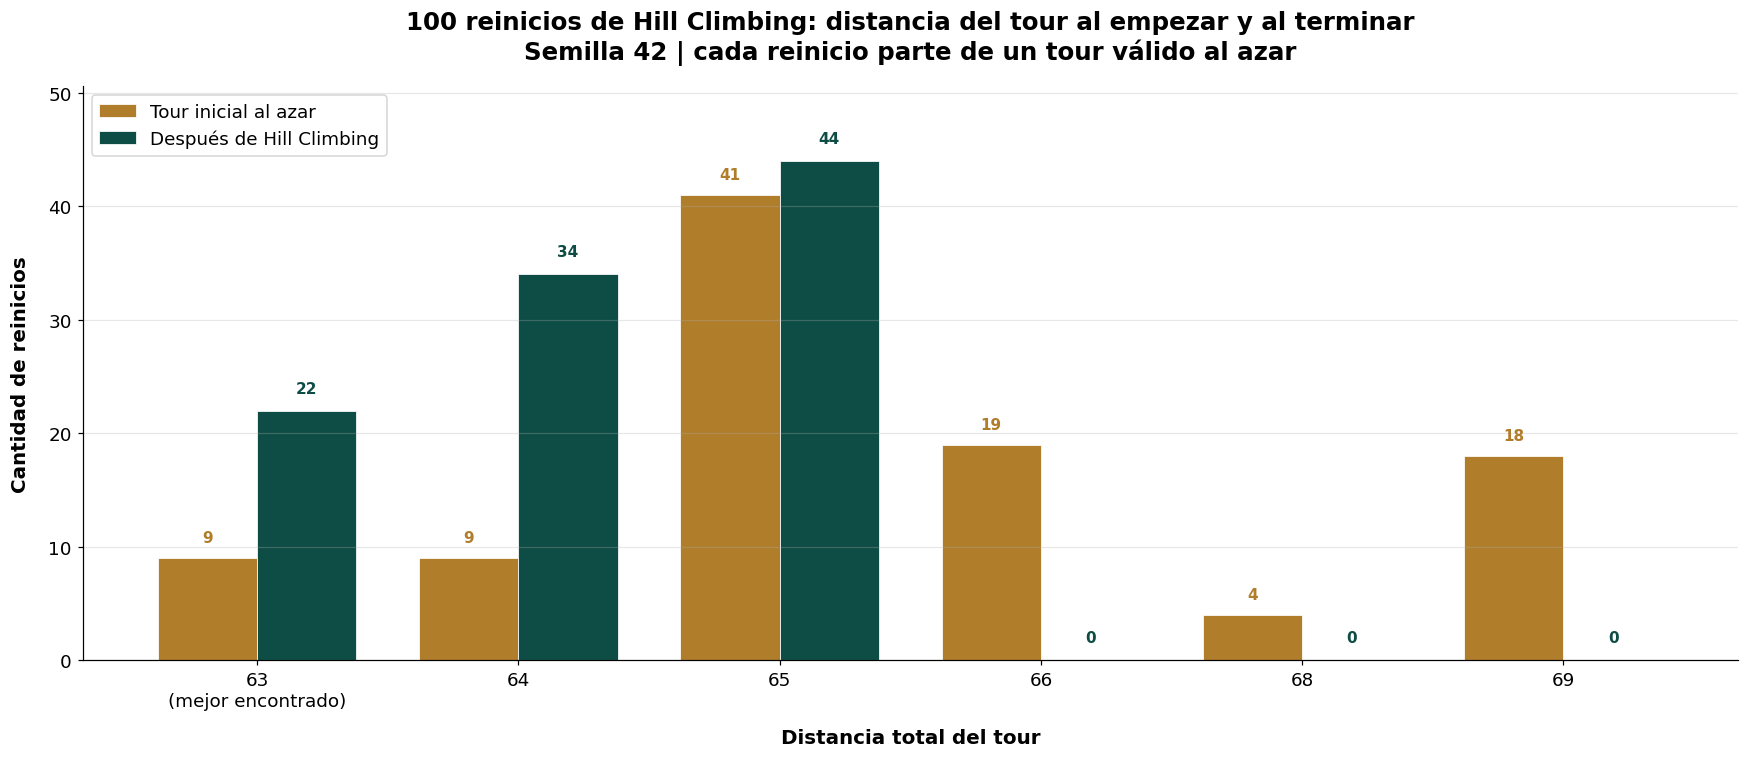

In [11]:
mejor_tour, mejor_dist, reinicios = hill_climbing_reinicios(distancias, 100, SEED)
print("Primeros 10 de los 100 reinicios:")
imprimir_tabla(reinicios[:10], ["reinicio", "intentos", "tour_inicial", "dist_inicial", "tour_final",
                                "dist_final", "movimientos"])

llegan = [r["reinicio"] for r in reinicios if r["dist_final"] == mejor_dist]
print(f"\nMejor tour con 100 reinicios: {formato(mejor_tour)} | distancia {mejor_dist}")
print(f"Reinicios que terminan en {mejor_dist}: {len(llegan)} de {len(reinicios)} (el primero es el {llegan[0]})")
print("Distancia inicial -> cantidad:", dict(sorted(Counter(r["dist_inicial"] for r in reinicios).items())))
print("Distancia final   -> cantidad:", dict(sorted(Counter(r["dist_final"] for r in reinicios).items())))
print(f"Barajadas promedio para obtener un tour válido: "
      f"{sum(r['intentos'] for r in reinicios) / len(reinicios):.1f}")
fig, ax = plot_reinicios(reinicios, mejor_dist, "01_hc_reinicios.png", etiqueta="mejor encontrado",
                         subtitulo=f"Semilla {SEED} | cada reinicio parte de un tour válido al azar")
plt.show()

Con 100 reinicios (semilla 42), el mejor tour es **1-3-5-7-6-4-2-1 con distancia 63**, 1 menos que Hill Climbing desde el tour inicial. Lo encuentra desde el primer reinicio. De los 100 reinicios, 22 terminan en 63, 34 en 64 y 44 en 65.

La gráfica muestra el efecto de cada escalada:

- **Antes** de Hill Climbing, los tours al azar van de 63 a 69.
- **Después**, ninguno queda arriba de 65. Hill Climbing siempre mejora lo que puede, pero 63, 64 y 65 son tres puntos donde se detiene.

Para conseguir un tour válido hicieron falta 34.2 barajadas en promedio. Cuadra con lo esperado: 720 órdenes / 20 válidos = 36.

### 7.5 Parte 1 | Extra: fuerza bruta de los tours válidos

In [12]:
validos = fuerza_bruta_tours(distancias)
optimo = validos[0][0]
print(f"Órdenes posibles de las ciudades 2 a 7: {math.factorial(len(distancias) - 1)} | "
      f"tours válidos: {len(validos)}\n")

# Run Hill Climbing from every valid tour to see where each one gets stuck.
filas = []
for d, t in validos:
    final, d_final, _ = hill_climbing(t, distancias)
    filas.append({"tour": t, "distancia": d, "hc_termina_en": d_final, "llega_al_optimo": d_final == optimo})
imprimir_tabla(filas, ["tour", "distancia", "hc_termina_en", "llega_al_optimo"])

exito = sum(f["llega_al_optimo"] for f in filas)
p = exito / len(filas)
print(f"\nÓptimo global: {optimo} ({sum(d == optimo for d, _ in validos)} tours: el mismo ciclo en los dos sentidos)")
print(f"Hill Climbing desde el tour inicial: {dist_hc} | mejor de 100 reinicios: {mejor_dist}")
print(f"Arranques válidos desde los que Hill Climbing llega al óptimo: {exito} de {len(filas)} ({p:.0%})")
print("Probabilidad de llegar al óptimo con k reinicios, 1 - (1 - p)^k:",
      {k: f"{1 - (1 - p) ** k:.1%}" for k in (1, 3, 5, 10, 100)})

Órdenes posibles de las ciudades 2 a 7: 720 | tours válidos: 20

tour            | distancia | hc_termina_en | llega_al_optimo
----------------+-----------+---------------+----------------
1-2-4-6-7-5-3-1 | 63        | 63            | sí             
1-3-5-7-6-4-2-1 | 63        | 63            | sí             
1-2-4-6-5-3-7-1 | 64        | 64            | no             
1-7-3-5-6-4-2-1 | 64        | 64            | no             
1-2-3-5-4-6-7-1 | 65        | 65            | no             
1-2-4-3-5-6-7-1 | 65        | 64            | no             
1-3-2-4-6-5-7-1 | 65        | 65            | no             
1-7-5-6-4-2-3-1 | 65        | 65            | no             
1-7-6-4-5-3-2-1 | 65        | 65            | no             
1-7-6-5-3-4-2-1 | 65        | 64            | no             
1-2-3-4-6-5-7-1 | 66        | 65            | no             
1-2-4-6-5-7-3-1 | 66        | 63            | sí             
1-3-7-5-6-4-2-1 | 66        | 63            | sí             
1-7-5

La fuerza bruta revisa los 720 órdenes y solo **20 son tours válidos**. El óptimo global es **63** y aparece dos veces: 1-2-4-6-7-5-3-1 y 1-3-5-7-6-4-2-1, que son el mismo ciclo en los dos sentidos. Con esto se confirma que:

- Hill Climbing desde el tour inicial (64) se quedó en un **óptimo local**.
- Los reinicios sí encontraron el **óptimo global**.

La columna `hc_termina_en` muestra a dónde lleva Hill Climbing desde cada arranque. Hay 8 tours donde se detiene sin moverse (los que terminan en su misma distancia): 2 de 63, 2 de 64 y 4 de 65. Solo **6 de los 20 arranques (30%)** llevan al óptimo. Como el tour al azar sale con la misma probabilidad entre los 20 válidos, cada reinicio tiene 30% de llegar a 63:

- Con 5 reinicios, la probabilidad de encontrarlo al menos una vez es 83.2%.
- Con 10 reinicios, 97.2%.
- Con 100, prácticamente 100%.

En la corrida de 7.4 llegaron 22 de 100, menos que los 30 esperados. Con 30% por reinicio, 22 o menos solo pasa en cerca del 5% de las corridas de 100: es una semilla algo desfavorable. Aun así no cambia la conclusión, porque el óptimo apareció desde el primer reinicio.

### 7.6 Parte 1 | Act. 6: gráfica del mejor recorrido

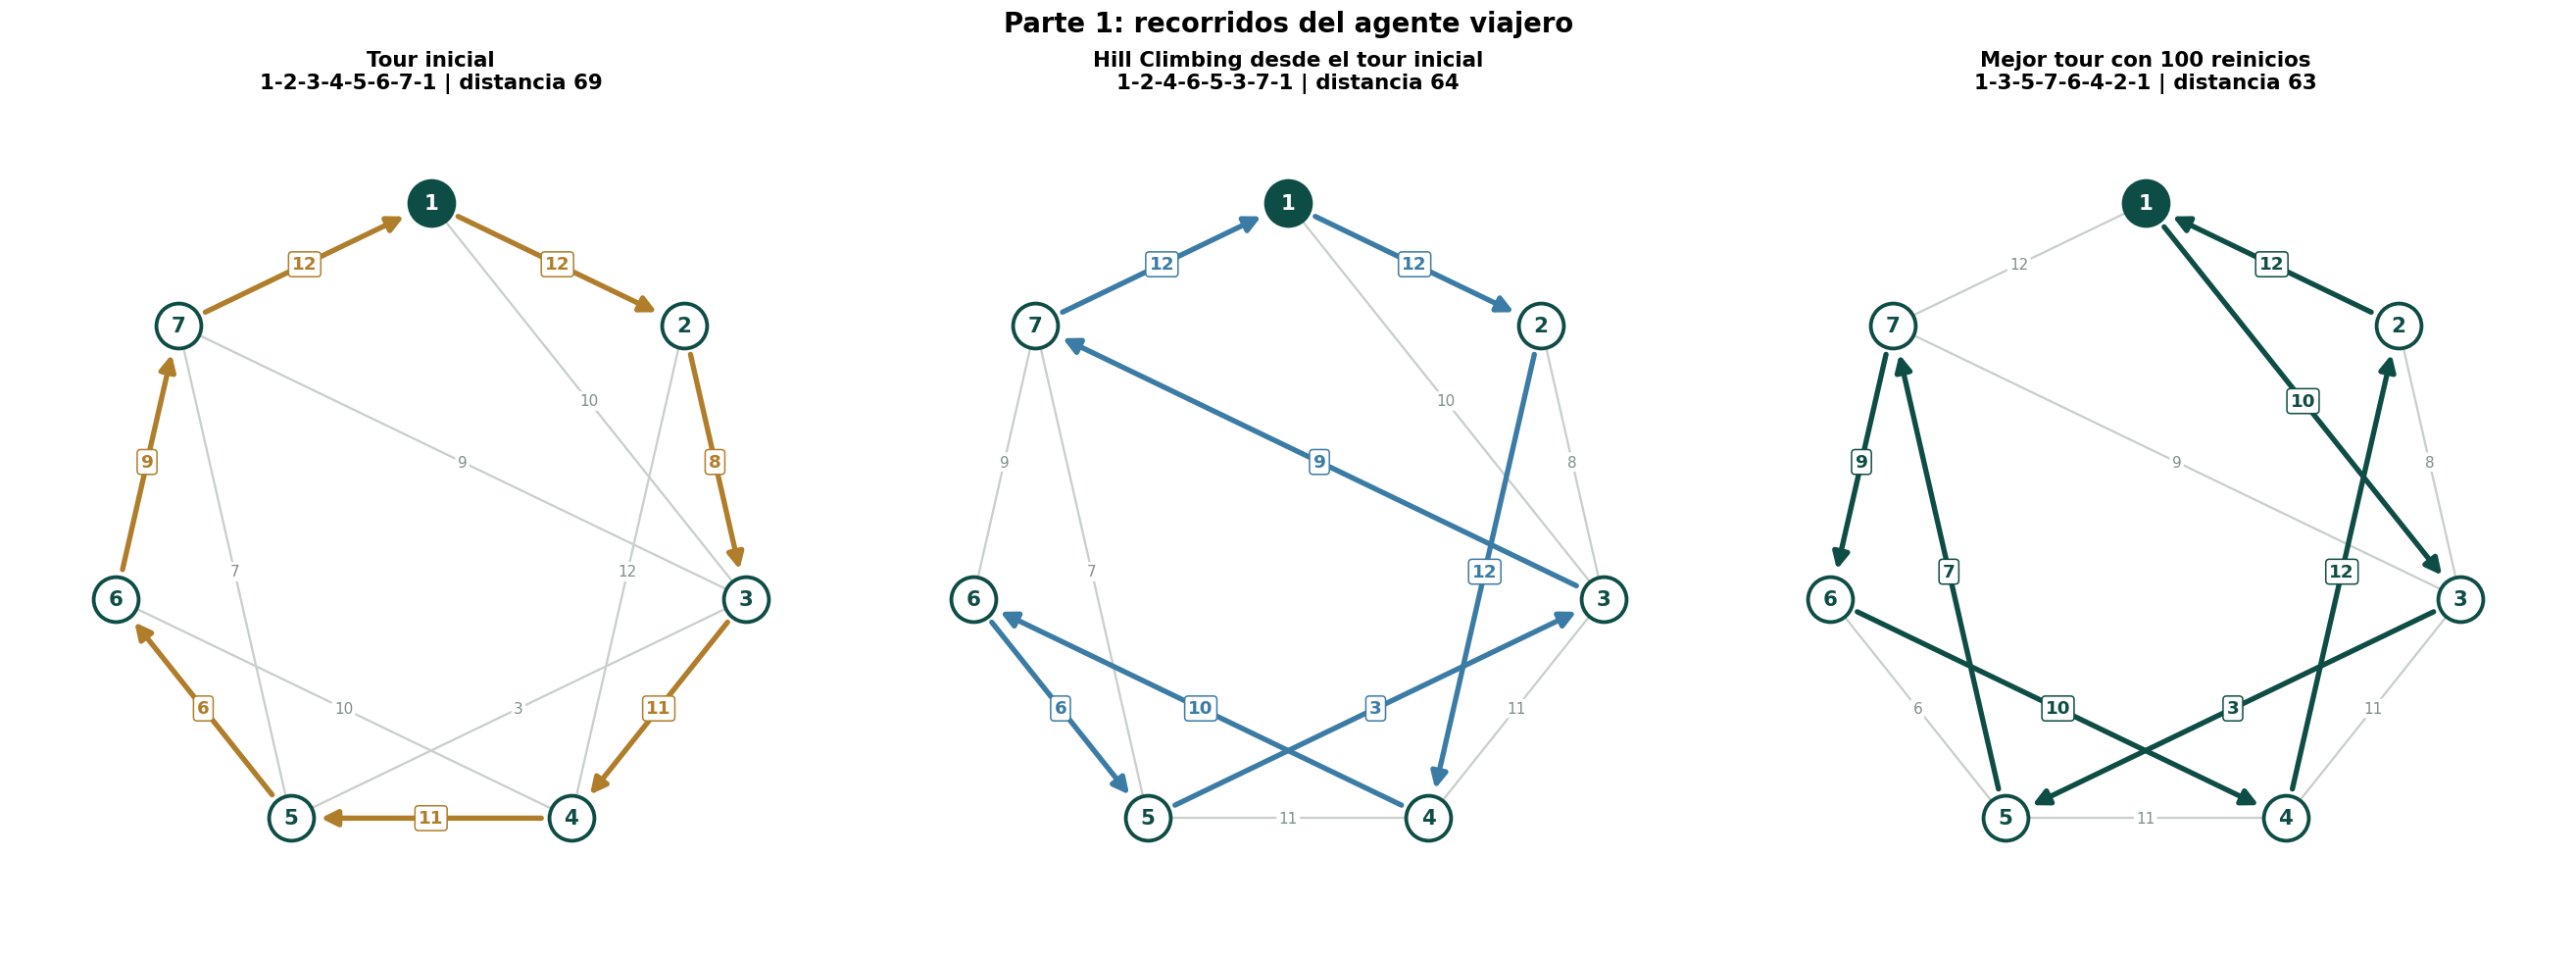

In [13]:
fig, axes = plot_tours([("Tour inicial", tour_inicial, ROLE["compare"]),
                        ("Hill Climbing desde el tour inicial", tour_hc, ROLE["model"]),
                        ("Mejor tour con 100 reinicios", mejor_tour, ROLE["actual"])],
                       distancias, "02_hc_mejor_recorrido.png", "Parte 1: recorridos del agente viajero")
plt.show()

Las posiciones de las ciudades son solo para dibujar. En gris están las carreteras que el tour no usa, y las flechas marcan el sentido del recorrido.

El panel del centro (64) y el de la derecha (63) explican por qué Hill Climbing se atasca. Leído en el mismo sentido, el óptimo es 1-2-4-6-7-5-3-1, así que los dos tours empiezan igual (1-2-4-6) y solo cambian en el final:

| Tour | Final del recorrido | Suma de esos tramos |
|---|---|---|
| Hill Climbing (64) | 6-5-3-7-1 | 6 + 3 + 9 + 12 = 30 |
| Óptimo (63) | 6-7-5-3-1 | 9 + 7 + 3 + 10 = 29 |

Pasar de 5-3-7 a 7-5-3 no es una inversión: hacen falta dos. La primera inversión (5-3-7 a 7-3-5) da 1-2-4-6-7-3-5-1, que no es válido porque no hay carretera de 5 a 1. El tour mejor está a dos pasos y el paso intermedio está prohibido, así que Hill Climbing, que solo mira un paso adelante, no lo puede ver.

#### Preguntas de análisis | Parte 1

**¿Qué representa una solución, un vecino y la función objetivo en este problema?**

- Una **solución** es un tour completo: sale de la ciudad 1, pasa exactamente una vez por las ciudades 2 a 7 y vuelve a la 1, usando solo carreteras que existen. Por ejemplo, 1-2-3-4-5-6-7-1.
- Un **vecino** es otro tour que se obtiene con un cambio pequeño: tomar un pedazo del recorrido y darle vuelta. Si en 1-2-3-4-5-6-7-1 se invierte el pedazo 3-4, queda 1-2-4-3-5-6-7-1. La ciudad 1 no se mueve. Con 7 ciudades hay 15 vecinos posibles, y aquí solo 5 de ellos son válidos.
- La **función objetivo** es la distancia total del tour, la suma de sus 7 tramos. Es el número que se quiere hacer lo más pequeño posible.

**¿Por qué Hill Climbing puede detenerse aunque exista un recorrido mejor?**

Porque solo compara el tour actual con sus vecinos inmediatos y solo acepta un cambio si mejora. Es como bajar una montaña con niebla, viendo solo un paso alrededor: si todos los pasos posibles suben o quedan igual, uno se detiene, aunque más allá haya un valle más profundo.

En este problema, desde el tour inicial llegó a 1-2-4-6-5-3-7-1 con 64. Ninguno de sus vecinos válidos mide menos de 64. El óptimo de 63 existe, pero para llegar a él hay que hacer dos inversiones, y la primera produce un tour que usa la carretera inexistente 5-1. Además, el algoritmo no acepta empates ni pasos peores, así que no tiene forma de cruzar ese punto intermedio.

**¿Qué efecto tuvieron los reinicios aleatorios?**

Convirtieron un método que dependía de la suerte del punto de partida en uno que encontró el óptimo:

- Una sola escalada desde el tour inicial termina en 64.
- Con 100 reinicios, el mejor resultado fue **63**, el óptimo global según la fuerza bruta. Lo alcanzaron 22 de los 100 reinicios, empezando por el primero.

Funciona porque cada reinicio empieza en otro lugar y cae en otra "zona" de atracción. El 30% de los arranques válidos lleva al óptimo, así que con 10 reinicios ya hay 97% de probabilidad de encontrarlo. El costo es correr Hill Climbing muchas veces, que aquí es barato porque cada escalada hace 2 movimientos o menos.

### 7.7 Parte 2 | Act. 7: heurística euclidiana

In [14]:
# TODO: call the functions for this step

TODO: interpretación de este resultado con los números reales.

### 7.8 Parte 2 | Act. 8 a 10: A\* paso a paso

In [15]:
# TODO: call the functions for this step

TODO: interpretación de este resultado con los números reales.

### 7.9 Parte 2 | Act. 11: A\* con h(n) = 0

In [16]:
# TODO: call the functions for this step

TODO: interpretación de este resultado con los números reales.

### 7.10 Parte 2 | Act. 12: gráfica de la red

In [17]:
# TODO: call the functions for this step

TODO: interpretación de este resultado con los números reales.

### 7.11 Parte 3A | Act. 13: red residual

In [18]:
# TODO: call the functions for this step

TODO: interpretación de este resultado con los números reales.

### 7.12 Parte 3A | Act. 14 a 16: Edmonds-Karp

In [19]:
# TODO: call the functions for this step

TODO: interpretación de este resultado con los números reales.

### 7.13 Parte 3A | Act. 17: verificación de capacidad y conservación

In [20]:
# TODO: call the functions for this step

TODO: interpretación de este resultado con los números reales.

### 7.14 Parte 3A | Extra: corte mínimo

In [21]:
# TODO: call the functions for this step

TODO: interpretación de este resultado con los números reales.

### 7.15 Parte 3B | Act. 18: estado inicial de cada arista

In [22]:
# TODO: call the functions for this step

TODO: interpretación de este resultado con los números reales.

### 7.16 Parte 3B | Act. 19 a 23: costo mínimo paso a paso

In [23]:
# TODO: call the functions for this step

TODO: interpretación de este resultado con los números reales.

### 7.17 Parte 3B | Act. 24: reporte final

In [24]:
# TODO: call the functions for this step

TODO: interpretación de este resultado con los números reales.

### 7.18 Parte 3B | Extra: costo de la distribución de Edmonds-Karp

In [25]:
# TODO: call the functions for this step

TODO: interpretación de este resultado con los números reales.

## 8. Conclusiones

TODO: respuesta a la pregunta con números, limitaciones y siguientes pasos.